In [3]:
import pandas as pd
import sqlite3
import os

In [4]:
DATA_DIR = "data"

patent_file = os.path.join(DATA_DIR, "g_patent.tsv")
inventor_file = os.path.join(DATA_DIR, "g_inventor_disambiguated.tsv")
assignee_file = os.path.join(DATA_DIR, "g_assignee_disambiguated.tsv")
uspc_file = os.path.join(DATA_DIR, "g_uspc_at_issue.tsv")

In [5]:
sample = pd.read_csv(patent_file, sep='\t', nrows=5)
print(sample.columns.tolist())

['patent_id', 'patent_type', 'patent_date', 'patent_title', 'wipo_kind', 'num_claims', 'withdrawn', 'filename']


In [6]:
# Adjust based on your machine RAM
CHUNK_SIZE = 100_000  

START_YEAR = 2000
END_YEAR = 2020

patent_cols = ['patent_id', 'patent_date']
inventor_cols = ['patent_id', 'inventor_id']
assignee_cols = ['patent_id', 'disambig_assignee_organization']
uspc_cols = ['patent_id', 'uspc_mainclass_id']

In [7]:
filtered_patents_list = []

for chunk in pd.read_csv(
    patent_file,
    sep='\t',
    usecols=patent_cols,
    chunksize=CHUNK_SIZE,
    low_memory=False
):
    chunk['patent_date'] = pd.to_datetime(chunk['patent_date'], errors='coerce')
    chunk['year'] = chunk['patent_date'].dt.year

    filtered = chunk[
        (chunk['year'] >= START_YEAR) &
        (chunk['year'] <= END_YEAR)
    ]

    filtered_patents_list.append(filtered)

patents_filtered = pd.concat(filtered_patents_list, ignore_index=True)

print("Filtered patents shape:", patents_filtered.shape)

Filtered patents shape: (5367164, 3)


In [8]:
valid_patent_ids = set(patents_filtered['patent_id'])

print("Total valid patents:", len(valid_patent_ids))

Total valid patents: 5367164


In [9]:
def filter_by_patent_ids(file_path, usecols, valid_ids, chunk_size=100_000):
    results = []

    for chunk in pd.read_csv(
        file_path,
        sep='\t',
        usecols=usecols,
        chunksize=chunk_size,
        low_memory=False
    ):
        filtered = chunk[chunk['patent_id'].isin(valid_ids)]
        results.append(filtered)

    return pd.concat(results, ignore_index=True)

In [10]:
sample_uspc = pd.read_csv(uspc_file, sep='\t', nrows=5)
print(sample_uspc.columns.tolist())

['patent_id', 'uspc_sequence', 'uspc_mainclass_id', 'uspc_mainclass_title', 'uspc_subclass_id', 'uspc_subclass_title']


In [11]:
inventors_filtered = filter_by_patent_ids(inventor_file, inventor_cols, valid_patent_ids)
assignees_filtered = filter_by_patent_ids(assignee_file, assignee_cols, valid_patent_ids)
uspc_filtered = filter_by_patent_ids(uspc_file, uspc_cols, valid_patent_ids)

print("Inventors:", inventors_filtered.shape)
print("Assignees:", assignees_filtered.shape)
print("USPC:", uspc_filtered.shape)

Inventors: (1110018, 2)
Assignees: (448626, 2)
USPC: (666940, 2)


In [12]:
conn = sqlite3.connect("patents.db")

patents_filtered.to_sql("patents", conn, if_exists="replace", index=False)
inventors_filtered.to_sql("inventors", conn, if_exists="replace", index=False)
assignees_filtered.to_sql("assignees", conn, if_exists="replace", index=False)
uspc_filtered.to_sql("uspc", conn, if_exists="replace", index=False)

print("Saved to database!")

Saved to database!


In [13]:
# Merge patents + inventors
pat_inv = pd.merge(
    patents_filtered[['patent_id']],
    inventors_filtered,
    on='patent_id',
    how='inner'
)

# Merge with assignees
relationships = pd.merge(
    pat_inv,
    assignees_filtered,
    on='patent_id',
    how='inner'
)

# Rename for clarity
relationships = relationships.rename(columns={
    'disambig_assignee_organization': 'company_name'
})

relationships.head()

,patent_id,inventor_id,company_name
0,9967824,fl:ji_ln:wu-462,"Beijing BOE Optoelectronics Technology Co., Ltd."
1,9967824,fl:ji_ln:wu-462,"BOE Technology Group Co., Ltd."
2,9967824,fl:li_ln:chen-259,"Beijing BOE Optoelectronics Technology Co., Ltd."
3,9967824,fl:li_ln:chen-259,"BOE Technology Group Co., Ltd."
4,9967824,fl:mu_ln:li-17,"Beijing BOE Optoelectronics Technology Co., Ltd."


In [14]:
relationships.to_sql("relationships", conn, if_exists="replace", index=False)

993891

In [22]:
q1 = pd.read_sql("""
SELECT inventor_id, COUNT(*) AS total_patents
FROM inventors
GROUP BY inventor_id
ORDER BY total_patents DESC
LIMIT 10
""", conn)

q1

,inventor_id,total_patents
0,fl:jo_ln:ive-4,1753
1,fl:ba_ln:andre-6,1473
2,fl:ri_ln:howarth-2,1466
3,fl:du_ln:kerr-1,1440
4,fl:ch_ln:stringer-4,1429
5,fl:da_ln:deiuliis-4,1413
6,fl:eu_ln:whang-8,1391
7,fl:ri_ln:zorkendorfer-1,1365
8,fl:da_ln:coster-2,1355
9,fl:ma_ln:rohrbach-2,1345


In [15]:
q2 = pd.read_sql("""
SELECT disambig_assignee_organization, COUNT(*) AS total
FROM assignees
GROUP BY disambig_assignee_organization
ORDER BY total DESC
LIMIT 10
""", conn)

q2

,disambig_assignee_organization,total
0,"SAMSUNG DISPLAY CO., LTD.",11834
1,None,6863
2,LG ELECTRONICS INC.,5267
3,"NIKE, Inc.",5100
4,Microsoft Corporation,3870
5,Apple Inc.,3189
6,SONY GROUP CORPORATION,2984
7,The Procter & Gamble Company,2615
8,"HONDA MOTOR CO., LTD.",2151
9,TOYOTA JIDOSHA KABUSHIKI KAISHA,1798


In [16]:
q4 = pd.read_sql("""
SELECT year, COUNT(*) AS total
FROM patents
GROUP BY year
ORDER BY year
""", conn)

q4

,year,total
0,2000,176192
1,2001,184172
2,2002,184494
3,2003,187104
4,2004,181413
5,2005,157829
6,2006,196489
7,2007,182978
8,2008,185260
9,2009,192052


In [17]:
q5 = pd.read_sql("""
SELECT p.patent_id, i.inventor_id, a.disambig_assignee_organization
FROM patents p
JOIN inventors i ON p.patent_id = i.patent_id
JOIN assignees a ON p.patent_id = a.patent_id
LIMIT 10
""", conn)

q5

,patent_id,inventor_id,disambig_assignee_organization
0,9967824,fl:bi_ln:zhao-50,"BOE Technology Group Co., Ltd."
1,9967824,fl:bi_ln:zhao-50,"Beijing BOE Optoelectronics Technology Co., Ltd."
2,9967824,fl:ji_ln:miao-59,"BOE Technology Group Co., Ltd."
3,9967824,fl:ji_ln:miao-59,"Beijing BOE Optoelectronics Technology Co., Ltd."
4,9967824,fl:ji_ln:wu-462,"BOE Technology Group Co., Ltd."
5,9967824,fl:ji_ln:wu-462,"Beijing BOE Optoelectronics Technology Co., Ltd."
6,9967824,fl:li_ln:chen-259,"BOE Technology Group Co., Ltd."
7,9967824,fl:li_ln:chen-259,"Beijing BOE Optoelectronics Technology Co., Ltd."
8,9967824,fl:mu_ln:li-17,"BOE Technology Group Co., Ltd."
9,9967824,fl:mu_ln:li-17,"Beijing BOE Optoelectronics Technology Co., Ltd."


In [18]:
q6 = pd.read_sql("""
WITH inventor_counts AS (
    SELECT inventor_id, COUNT(*) AS total
    FROM inventors
    GROUP BY inventor_id
)
SELECT *
FROM inventor_counts
WHERE total > 10
ORDER BY total DESC
LIMIT 10
""", conn)

q6

,inventor_id,total
0,fl:jo_ln:ive-4,1753
1,fl:ba_ln:andre-6,1473
2,fl:ri_ln:howarth-2,1466
3,fl:du_ln:kerr-1,1440
4,fl:ch_ln:stringer-4,1429
5,fl:da_ln:deiuliis-4,1413
6,fl:eu_ln:whang-8,1391
7,fl:ri_ln:zorkendorfer-1,1365
8,fl:da_ln:coster-2,1355
9,fl:ma_ln:rohrbach-2,1345


In [19]:
q7 = pd.read_sql("""
SELECT inventor_id, total,
       RANK() OVER (ORDER BY total DESC) as rank
FROM (
    SELECT inventor_id, COUNT(*) as total
    FROM inventors
    GROUP BY inventor_id
)
LIMIT 10
""", conn)

q7

,inventor_id,total,rank
0,fl:jo_ln:ive-4,1753,1
1,fl:ba_ln:andre-6,1473,2
2,fl:ri_ln:howarth-2,1466,3
3,fl:du_ln:kerr-1,1440,4
4,fl:ch_ln:stringer-4,1429,5
5,fl:da_ln:deiuliis-4,1413,6
6,fl:eu_ln:whang-8,1391,7
7,fl:ri_ln:zorkendorfer-1,1365,8
8,fl:da_ln:coster-2,1355,9
9,fl:ma_ln:rohrbach-2,1345,10


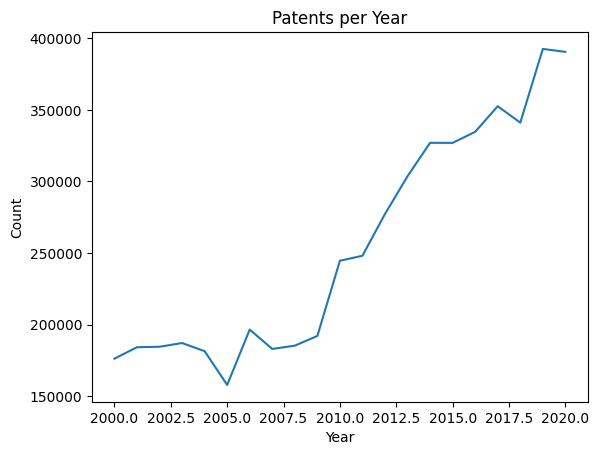

In [20]:
import matplotlib.pyplot as plt

patents_per_year = q4  # q4 has 'year' and 'total' columns

plt.figure()
plt.plot(patents_per_year['year'], patents_per_year['total'])
plt.title("Patents per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [23]:
q1.to_csv("top_inventors.csv", index=False)
q2.to_csv("top_companies.csv", index=False)
q4.to_csv("country_trends.csv", index=False)

In [24]:
import json

report = {
    "total_patents": len(patents_filtered),
    "top_inventors": q1.to_dict(orient="records"),
    "top_companies": q2.to_dict(orient="records"),
    "patents_per_year": q4.to_dict(orient="records")
}

with open("report.json", "w") as f:
    json.dump(report, f, indent=4)

print("JSON report saved!")

JSON report saved!


In [25]:
print("="*50)
print("PATENT REPORT")
print("="*50)

print(f"Total Patents: {len(patents_filtered)}\n")

print("Top Inventors:")
print(q1.head(), "\n")

print("Top Companies:")
print(q2.head(), "\n")

print("Patents Per Year:")
print(q4.head())

PATENT REPORT
Total Patents: 5367164

Top Inventors:
           inventor_id  total_patents
0       fl:jo_ln:ive-4           1753
1     fl:ba_ln:andre-6           1473
2   fl:ri_ln:howarth-2           1466
3      fl:du_ln:kerr-1           1440
4  fl:ch_ln:stringer-4           1429 

Top Companies:
  disambig_assignee_organization  total
0      SAMSUNG DISPLAY CO., LTD.  11834
1                           None   6863
2            LG ELECTRONICS INC.   5267
3                     NIKE, Inc.   5100
4          Microsoft Corporation   3870 

Patents Per Year:
   year   total
0  2000  176192
1  2001  184172
2  2002  184494
3  2003  187104
4  2004  181413


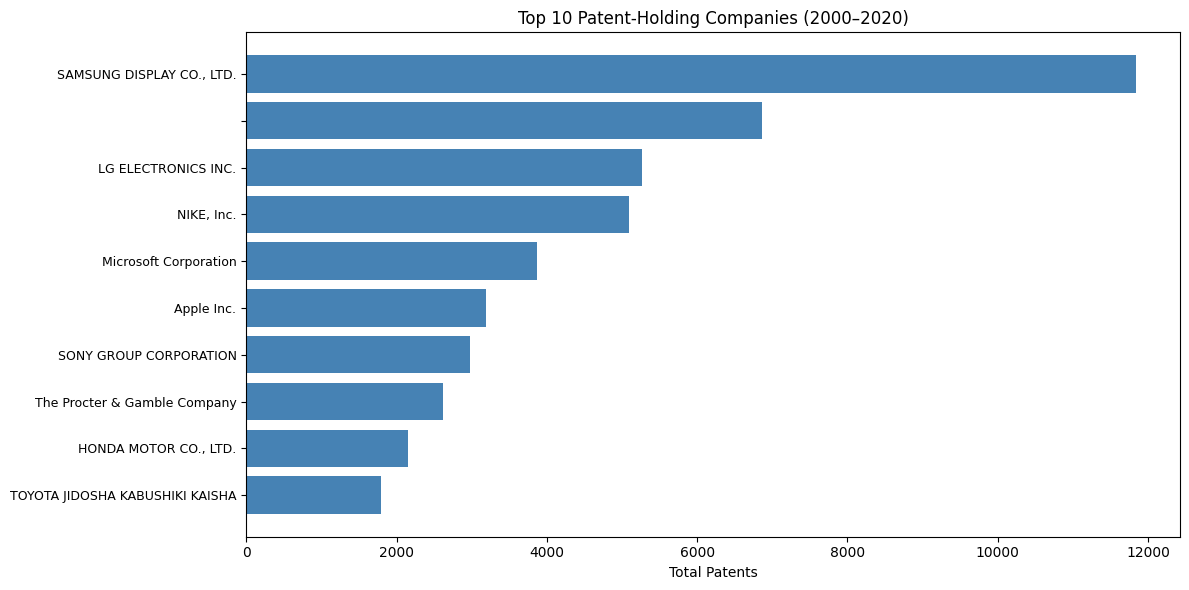

In [29]:
import matplotlib.pyplot as plt

top10 = q2.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(10), top10['total'].values[::-1], color='steelblue')
ax.set_yticks(range(10))
ax.set_yticklabels(top10['disambig_assignee_organization'].values[::-1], fontsize=9)
ax.set_xlabel("Total Patents")
ax.set_title("Top 10 Patent-Holding Companies (2000–2020)")
plt.tight_layout()
plt.show()

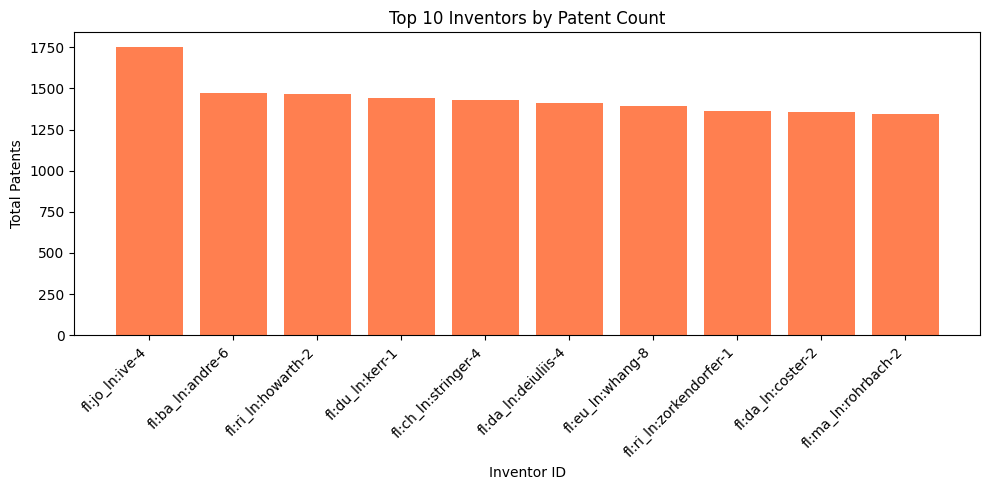

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(q1['inventor_id'].astype(str), q1['total_patents'], color='coral')
ax.set_xlabel("Inventor ID")
ax.set_ylabel("Total Patents")
ax.set_title("Top 10 Inventors by Patent Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

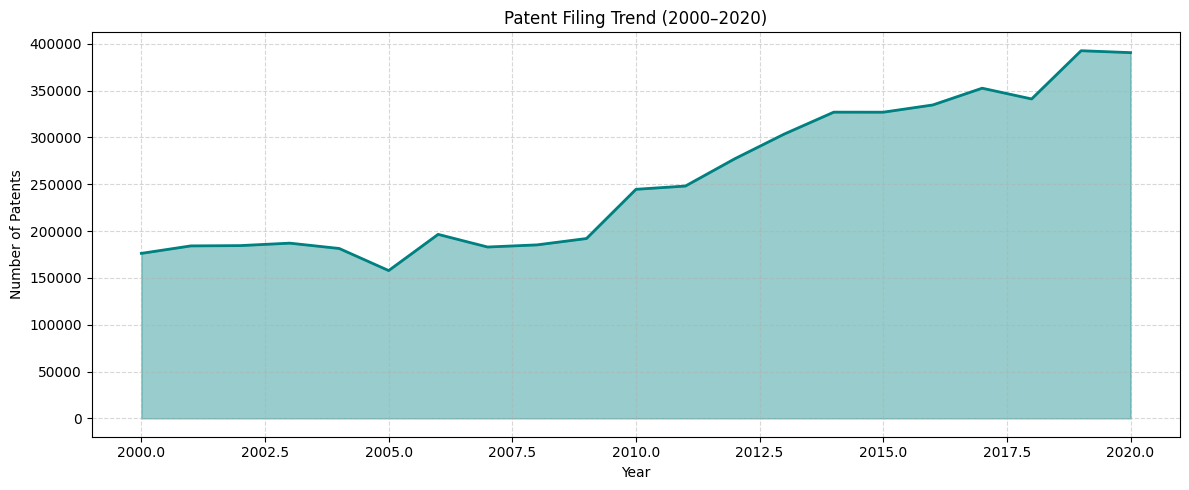

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(q4['year'], q4['total'], alpha=0.4, color='teal')
ax.plot(q4['year'], q4['total'], color='teal', linewidth=2)
ax.set_title("Patent Filing Trend (2000–2020)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Patents")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

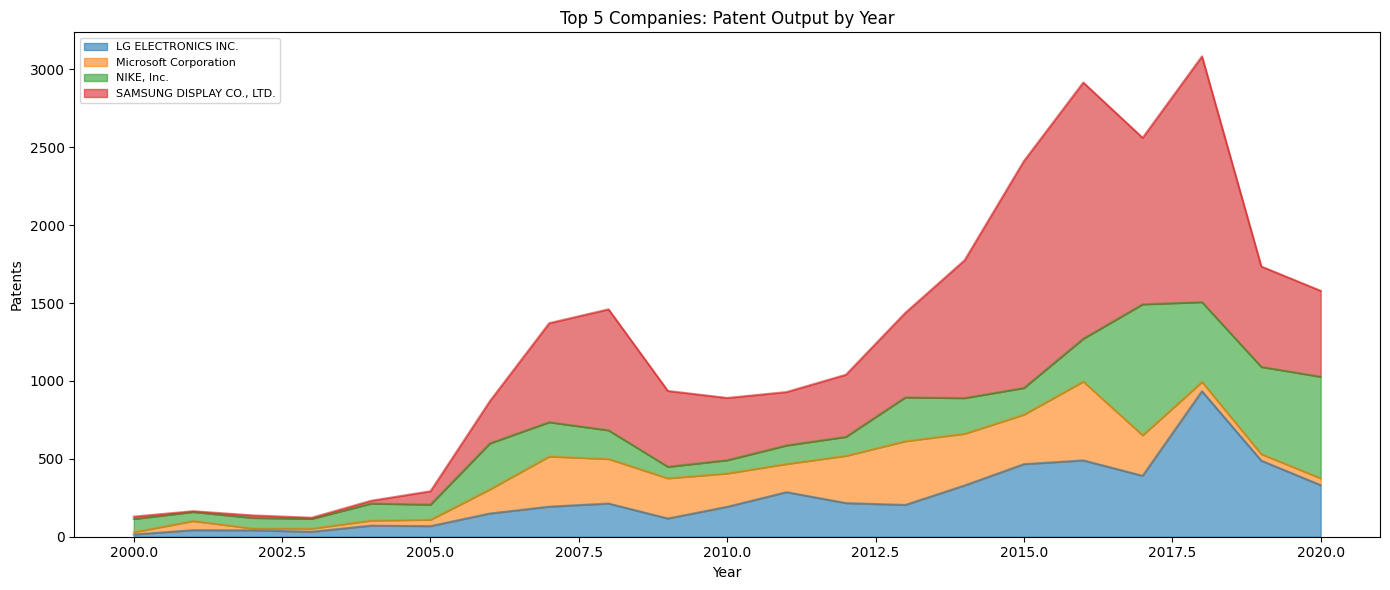

In [32]:
top5_companies = q2['disambig_assignee_organization'].head(5).tolist()

co_year = pd.read_sql(f"""
    SELECT p.year, a.disambig_assignee_organization AS company, COUNT(*) AS total
    FROM patents p
    JOIN assignees a ON p.patent_id = a.patent_id
    WHERE a.disambig_assignee_organization IN ({','.join(['?']*len(top5_companies))})
    GROUP BY p.year, company
    ORDER BY p.year
""", conn, params=top5_companies)

pivot = co_year.pivot(index='year', columns='company', values='total').fillna(0)

pivot.plot.area(figsize=(14, 6), alpha=0.6)
plt.title("Top 5 Companies: Patent Output by Year")
plt.xlabel("Year")
plt.ylabel("Patents")
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()